In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["acsf"])
df = qm9.load()

2026-05-06 09:37:44.415 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-06 09:37:44.820 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-05-06 09:37:44.821 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-05-06 09:37:44.827 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-06 09:37:47.662 | SUCCESS  | src.datasets:add_acsf:1262 - Added ACSF embeddings and matrices.
2026-05-06 09:37:47.662 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['acsf_embedding', 'acsf_matrix']
2026-05-06 09:37:47.671 | INFO     | src.datasets:load:907 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=5000, returned_rows=5000, base_rows=5500.


In [4]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="acsf",
    dist_type="euclidean",
    force_calculate=True,
)

2026-05-06 09:37:47.692 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for acsf using euclidean distance.
2026-05-06 09:37:48.145 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_acsf_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:10<00:00,  1.03s/it]


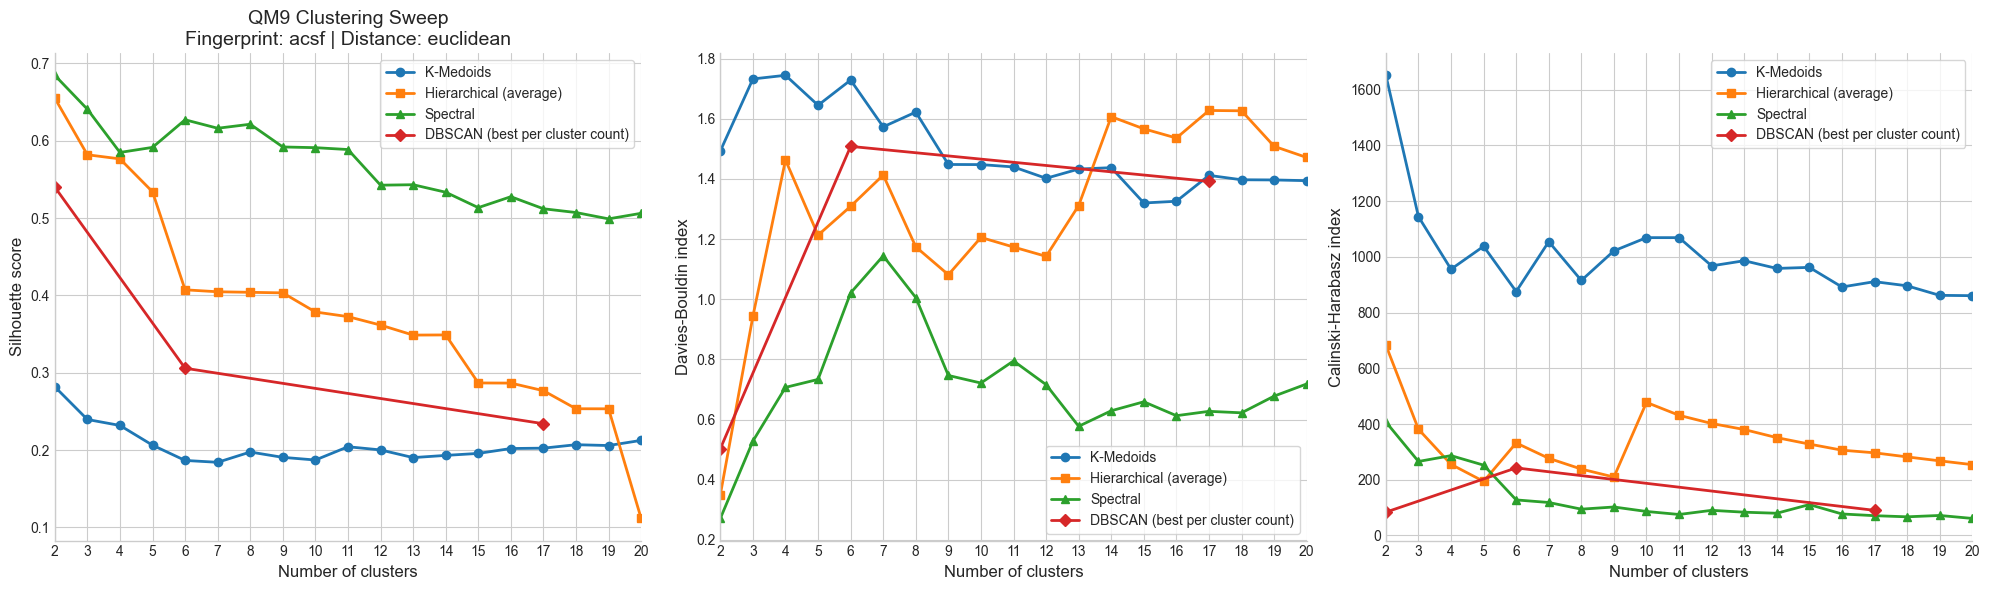

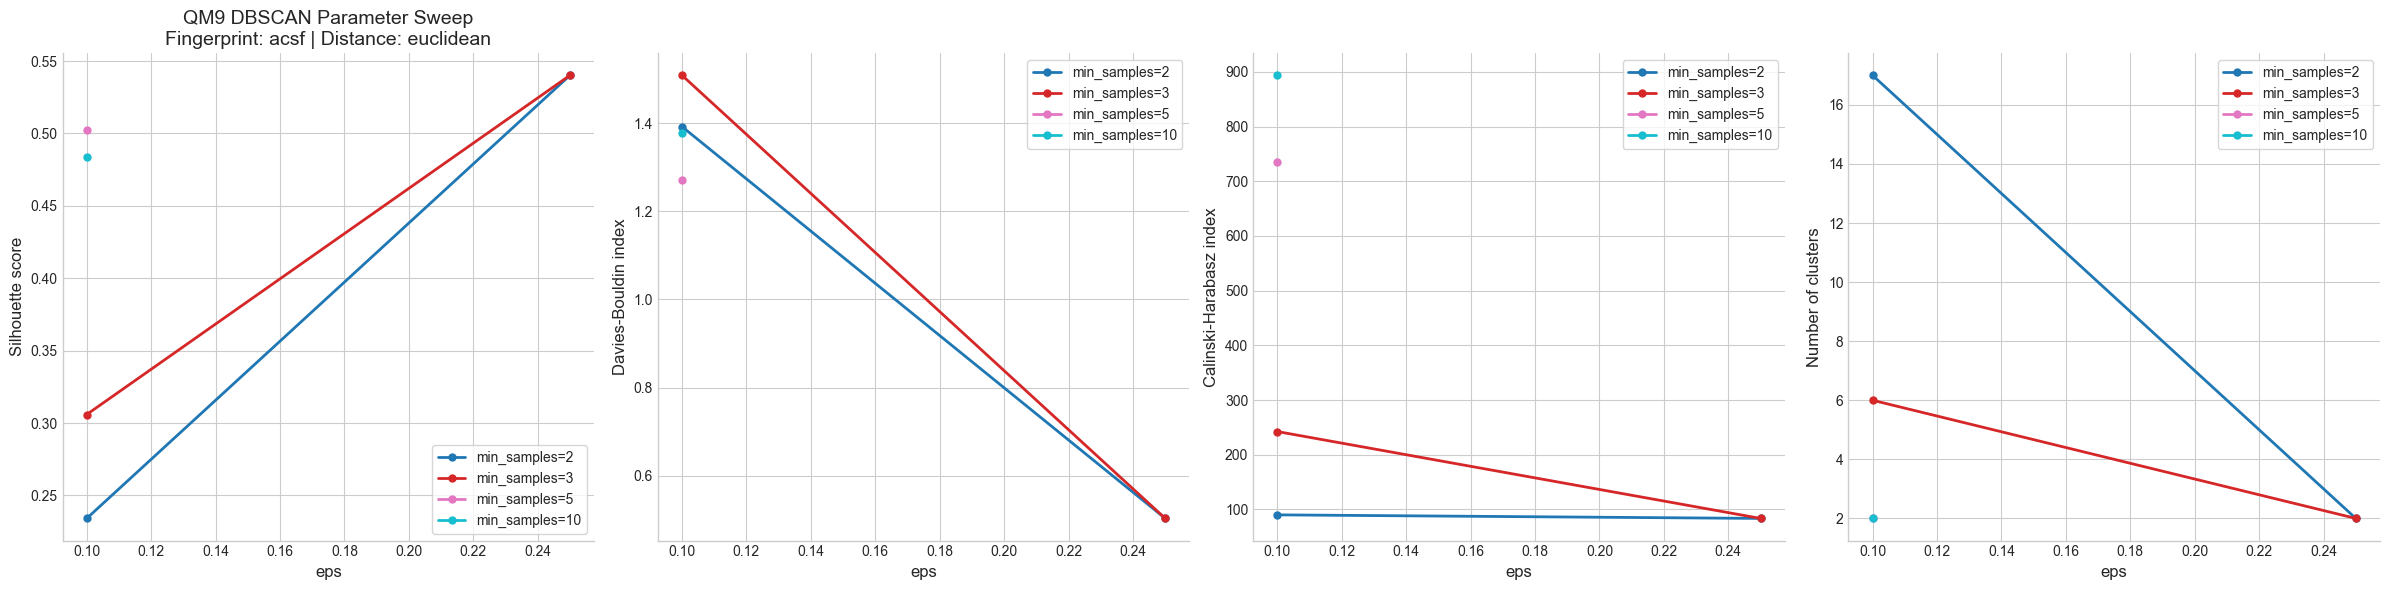

2026-05-06 09:38:54.100 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1059 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.png
2026-05-06 09:38:54.100 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1061 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/acsf/dbscan_parameter_sweep.png
2026-05-06 09:38:54.100 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved clustering sweep results to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.json


In [5]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    dataset_name="qm9",
)

# Hiercical Clustering on Distance Matrix

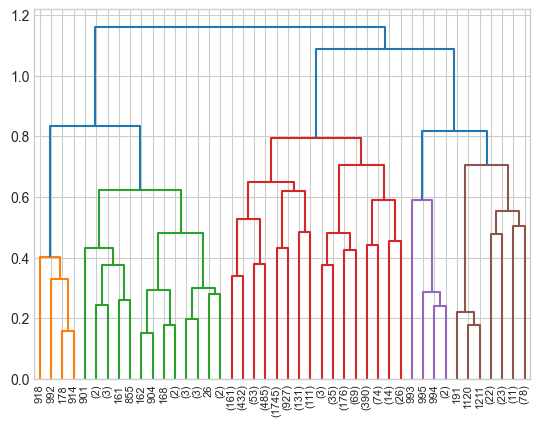

In [6]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [35]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=5, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [8]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-05-06 09:38:55.129 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-06 09:38:55.130 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-06 09:39:43.056 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-06 09:39:43.072 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-06 09:39:43.314 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-06 09:39:43.381 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

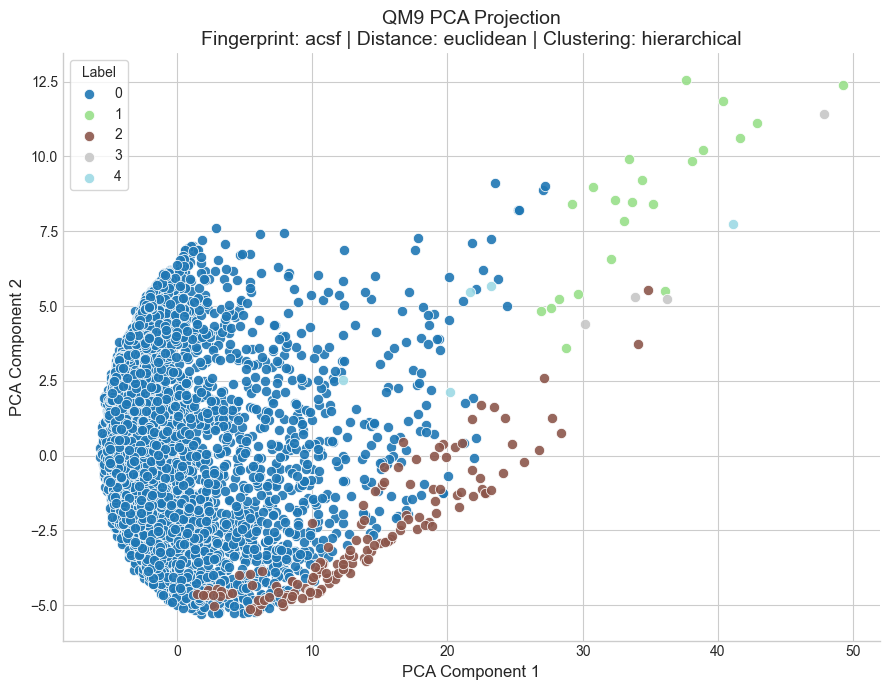

2026-05-07 08:28:36.873 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hierarchical_projection.png


In [36]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [10]:
average_numeric_by_cluster(df, "labels_hier")

shape: (2, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4974,0.758739,0.0,122.686972,0.062324,35.545637,0.882225,12.830157,8.778247,1.70185,0.105951,0.004222,2.331122,18.531765,2.065047,2.30579,0.06829,0.195964,0.735746,0.934861,1.938681,6.568154,0.449337,1.161238,4.83655,6.345999,13.819059,1.262883,0.001608,0.383796,0.022718,0.126055,0.136711,0.001407,0.041214,0.133896,0.542018,0.0,2.660446,75.469916,-6.535894,0.383241,6.919142,1190.605676,4.124965,-11124.274281,-11124.041617,-11124.015924,-11125.185435,31.908852,-76.934534,-77.405066,-77.848308,-71.598931,3.365202,1.395487,1.124486,79.272216,10.35384,10.373945,13.819059,1463,"""Acyclic""",10.373945,341,"""C1CCCC1""",10.695617,1,null,0.0
1,26,1.02959,0.0,109.192308,-0.307692,74.076923,0.233312,13.349358,7.807692,1.0,0.923077,0.115385,4.923077,10.884615,2.0,1.0,0.073077,0.882051,0.044872,0.923077,4.076923,3.692308,0.269231,2.5,0.115385,5.461538,11.115385,1.272303,0.0,0.0,0.115385,0.423077,0.038462,0.0,0.0,0.0,0.115385,0.038462,3.4076,56.118462,-7.208924,-1.746029,5.462476,797.391428,1.944974,-11069.337816,-11069.167462,-11069.141977,-11070.171255,22.441885,-47.506057,-47.749413,-47.999447,-44.339124,5.54853,2.123687,1.493317,7.692308,88.461538,3.846154,11.115385,22,"""c1ncon1""",11.538462,8,"""C1CCCCC1""",38.461538,1,null,0.0


# KMedoids

In [42]:
model_km = KMedoids(n_clusters=2, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1], dtype=uint64), array([2566, 2434]))


In [12]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-06 09:39:44.730 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-06 09:39:44.731 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-06 09:40:33.029 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-06 09:40:33.041 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-06 09:40:33.279 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-06 09:40:33.348 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

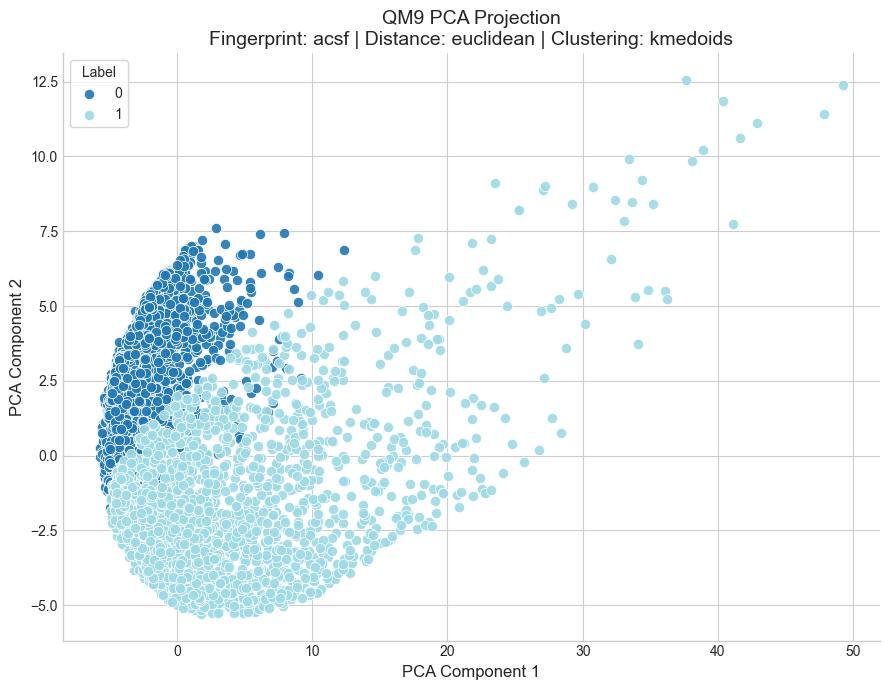

2026-05-07 08:31:06.227 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png


{'coords': array([[ 2.04727382,  6.15755566],
        [ 0.78826238,  2.45460851],
        [ 2.92098853,  4.15312476],
        ...,
        [-2.79477572,  1.8261195 ],
        [-3.19933111, -0.19352697],
        [ 1.28699442,  5.14097104]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'kmedoids'}

In [43]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [14]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1691,0.82996,0.0,123.369012,-0.065642,39.248374,0.971078,12.771435,8.810171,1.864577,0.066824,0.00887,2.604376,16.958013,2.085524,1.864577,0.080468,0.213631,0.705901,0.761679,2.366647,5.937315,0.52809,1.273802,4.403903,6.176227,13.956239,1.273059,0.002957,0.48906,0.019515,0.073921,0.101124,0.0,0.096393,0.232407,0.907156,0.0,2.710729,71.319834,-6.68867,-0.060819,6.62785,1125.366688,3.640882,-11633.935735,-11633.713841,-11633.688159,-11634.836244,30.379326,-72.237608,-72.661709,-73.066769,-67.316337,3.386311,1.46086,1.177872,0.000591,84.979302,6.6233,8.397398,13.956239,690,"""Acyclic""",8.397398,241,"""Acyclic""",8.397398,1,null,0.0
1,1161,0.825968,0.0,120.745909,-0.354005,46.768303,0.692147,12.916787,8.742463,1.747631,0.354005,0.007752,3.002584,16.710594,2.07341,1.572782,0.094893,0.368929,0.536179,1.387597,2.20155,6.489233,0.574505,1.959518,3.205857,6.185185,13.64944,1.263017,0.002584,0.118002,0.068045,0.319552,0.229974,0.002584,0.011197,0.090439,0.167959,0.000861,3.21992,73.517201,-6.286838,-0.130528,6.156294,1102.704278,3.504907,-11060.079271,-11059.863214,-11059.837505,-11060.970589,29.596251,-69.975322,-70.382705,-70.772751,-65.213218,3.597984,1.499223,1.154776,0.021533,59.173127,34.366925,6.459948,13.64944,517,"""Acyclic""",6.459948,158,"""C1CCCC1""",21.016365,1,null,0.0
2,2148,0.669612,0.0,123.035847,0.383613,27.031192,0.907159,12.835847,8.760708,1.540503,0.01257,0.0,1.784451,20.662477,2.04362,3.03352,0.044382,0.096872,0.858746,0.82635,1.485568,7.072626,0.317505,0.657356,6.001397,6.555866,13.770019,1.254912,0.0,0.439944,0.001862,0.066108,0.113128,0.001862,0.013501,0.078212,0.451583,0.0,2.327508,79.558254,-6.558385,0.984746,7.543149,1284.716049,4.814811,-10757.079001,-10756.829638,-10756.803946,-10758.008316,34.248339,-84.037424,-84.57589,-85.075604,-78.091913,3.249191,1.296768,1.070551,0.0,84.776536,1.256983,13.96648,13.770019,570,"""Acyclic""",13.96648,172,"""C1CC1""",15.037244,1,null,0.0


# Spectral

In [31]:
gaussian_kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))

model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(gaussian_kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4984,    7,    9]))


In [16]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-06 09:40:35.854 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-06 09:40:35.855 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-06 09:41:24.252 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-06 09:41:24.277 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-06 09:41:24.561 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-06 09:41:25.496 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

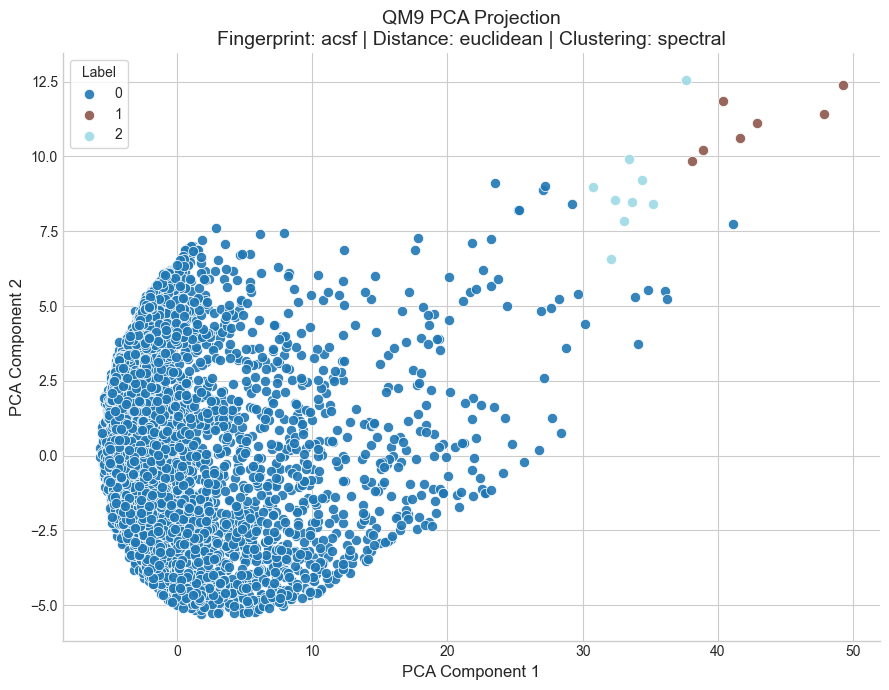

2026-05-07 08:20:12.826 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_spectral_projection.png


In [32]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
_=average_numeric_by_cluster(df, "labels_spectral")

shape: (6, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4965,0.758185,0.0,122.698489,0.062437,35.521652,0.881632,12.828871,8.780262,1.703726,0.105136,0.001813,2.326888,18.544411,2.06529,2.306143,0.068343,0.195483,0.736173,0.935146,1.936556,6.573615,0.44995,1.160926,4.842497,6.347633,13.822558,1.262849,0.001611,0.383887,0.022356,0.12568,0.136959,0.00141,0.041088,0.133938,0.542195,0.0,2.659116,75.522453,-6.534975,0.384458,6.919437,1191.140718,4.128622,-11120.879242,-11120.64651,-11120.620816,-11121.790468,31.922066,-76.98565,-77.456589,-77.900147,-71.646371,3.361551,1.395138,1.124153,0.000604,1.093656,79.39577,10.271903,10.332326,13.822558,1463,"""Acyclic""",10.332326,341,"""C1CCCC1""",10.6143,1,null,0.0
1,3,1.248822,0.0,120.666667,0.333333,20.0,1.818446,13.963281,7.666667,0.0,0.0,3.0,4.333333,10.0,1.798653,0.666667,0.166667,0.305556,0.527778,0.0,1.333333,2.666667,0.666667,1.0,1.666667,4.666667,12.333333,1.309968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,2.5595,40.893333,-7.90128,-1.373268,6.528011,848.776001,1.556228,-14372.705404,-14372.508138,-14372.482747,-14373.593424,24.277334,-44.128184,-44.316343,-44.547592,-41.269073,4.30951,1.506997,1.383463,0.0,0.0,0.0,0.0,100.0,12.333333,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
2,2,1.266667,0.0,114.5,-0.5,87.5,0.260064,13.453146,8.0,1.0,1.0,0.0,6.0,9.5,2.0,1.0,0.0,1.0,0.0,0.0,4.5,3.0,0.0,2.0,0.0,5.0,12.0,1.291803,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,3.2891,50.734999,-8.36478,-3.051757,5.311662,784.506683,1.487361,-12426.231934,-12426.06543,-12426.039551,-12427.080566,21.179501,-40.999033,-41.198982,-41.417351,-38.172205,4.93694,1.908915,1.360165,1.0,1.0,0.0,100.0,0.0,12.0,2,"""O=c1[nH+]cnno1""",50.0,2,"""CC1CCCCC1""",50.0,1,null,0.0
3,10,0.976955,0.0,107.3,-0.4,71.6,0.039932,13.490144,7.7,1.1,1.0,0.2,5.0,11.2,2.016667,1.0,0.066667,0.85,0.083333,1.0,4.1,3.9,0.2,2.3,0.2,5.5,10.9,1.269339,0.0,0.0,0.1,0.5,0.0,0.0,0.0,0.0,0.0,0.0,3.76861,57.045,-6.928563,-1.556763,5.371528,758.940054,2.026786,-10654.952246,-10654.784619,-10654.759082,-10655.778564,22.1816,-47.149102,-47.401677,-47.656067,-43.934877,5.678166,2.28743,1.592384,1.0,1.0,10.0,90.0,0.0,10.9,10,"""C1=NNON=C1""",10.0,3,"""C1CCCCC1""",70.0,1,null,0.0
4,1,1.090909,0.0,124.0,0.0,20.0,1.7250676,13.792997,8.0,0.0,0.0,3.0,4.0,11.0,1.818182,1.0,0.5,0.0,0.5,1.0,1.0,2.0,2.0,0.0,2.0,6.0,12.0,1.293238,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.8806,48.369999,-7.711707,-0.209528,7.502179,1295.820557,1.814156,-14390.896484,-14390.672852,-14390.647461,-14391.844727,27.172001,-47.540035,-47.739033,-47.995991,-44.419163,4.76814,0.85562,0.83555,0.0,0.0,0.0,0.0,100.0,12.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
5,19,1.011164,0.0,110.421053,-0.210526,73.368421,0.465793,13.234309,7.789474,1.0,0.894737,0.052632,4.789474,11.315789,2.0,1.578947,0.030702,0.824561,0.144737,1.052632,4.157895,3.842105,0.105263,2.473684,0.421053,5.

# DBSCAN 

In [19]:
model_db = DBSCAN(
    eps=0.6,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([0]), array([5000]))


In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-06 09:41:26.643 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-06 09:41:26.643 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-06 09:42:14.815 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-06 09:42:14.823 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-06 09:42:15.133 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-06 09:42:15.201 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

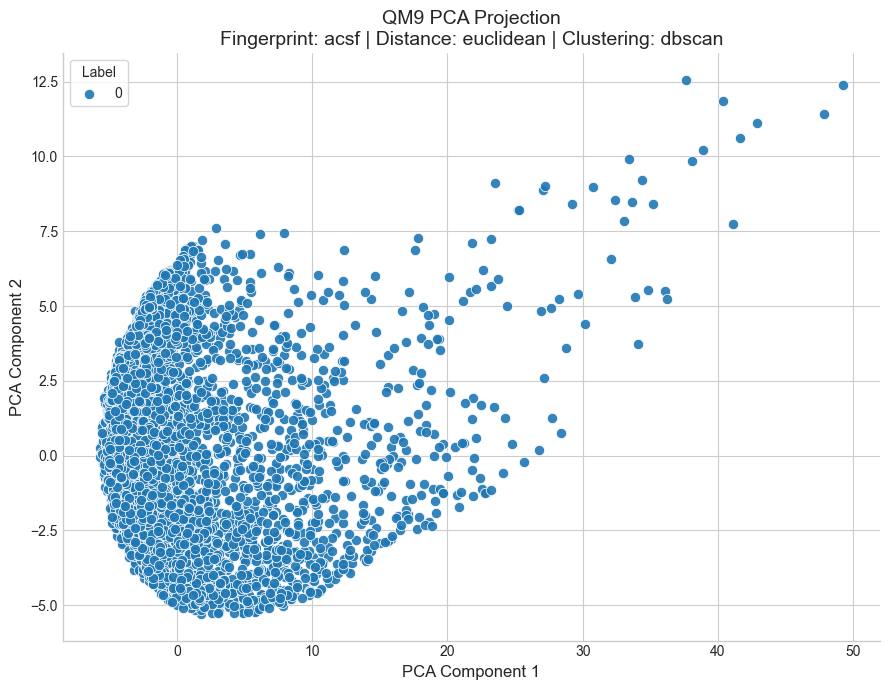

2026-05-06 09:42:15.722 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_dbscan_projection.png


{'coords': array([[ 2.04727382,  6.15755566],
        [ 0.78826238,  2.45460851],
        [ 2.92098853,  4.15312476],
        ...,
        [-2.79477572,  1.8261195 ],
        [-3.19933111, -0.19352697],
        [ 1.28699442,  5.14097104]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'dbscan'}

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [22]:
average_numeric_by_cluster(df, "labels_db")

shape: (1, 74)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,5000,0.760148,0.0,122.6168,0.0604,35.746,0.878851,12.832857,8.7732,1.6982,0.1102,0.0048,2.3446,18.492,2.064709,2.299,0.068315,0.199532,0.732154,0.9348,1.9498,6.5532,0.4484,1.1682,4.812,6.3414,13.805,1.262932,0.0016,0.3818,0.0232,0.1276,0.1362,0.0014,0.041,0.1332,0.5398,0.0002,2.664332,75.369288,-6.539394,0.372169,6.911567,1188.560962,4.113629,-11123.988611,-11123.756272,-11123.730579,-11124.899361,31.859624,-76.781506,-77.250857,-77.693094,-71.45718,3.376555,1.399274,1.126404,0.0052,1.0914,0.0272,78.9,10.76,10.34,13.805,1478,"""Acyclic""",10.34,342,"""C1CCCC1""",10.8,1,null,0.0


In [23]:
from src.helper_functions import evaluate_hdbscan_grid
import hdbscan
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=20, ms=1, clusters=49, noise=0.32, persistence=0.088, score=0.059
mcs=40, ms=1, clusters=27, noise=0.43, persistence=0.096, score=0.054
mcs=60, ms=1, clusters=20, noise=0.49, persistence=0.106, score=0.054
mcs=10, ms=1, clusters=74, noise=0.30, persistence=0.074, score=0.052
mcs=10, ms=1, clusters=74, noise=0.30, persistence=0.074, score=0.052
mcs=10, ms=2, clusters=65, noise=0.36, persistence=0.077, score=0.049
mcs=20, ms=2, clusters=47, noise=0.38, persistence=0.077, score=0.048
mcs=60, ms=10, clusters=2, noise=0.32, persistence=0.067, score=0.046
mcs=40, ms=20, clusters=2, noise=0.42, persistence=0.075, score=0.043
mcs=300, ms=1, clusters=2, noise=0.50, persistence=0.084, score=0.042
mcs=80, ms=10, clusters=2, noise=0.32, persistence=0.059, score=0.040
mcs=220, ms=1, clusters=2, noise=0.50, persistence=0.079, score=0.040


In [44]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=20,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-06 09:42:51.724 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-06 09:42:51.725 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-06 09:43:40.111 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-06 09:43:40.125 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-06 09:43:40.377 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-06 09:43:40.446 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

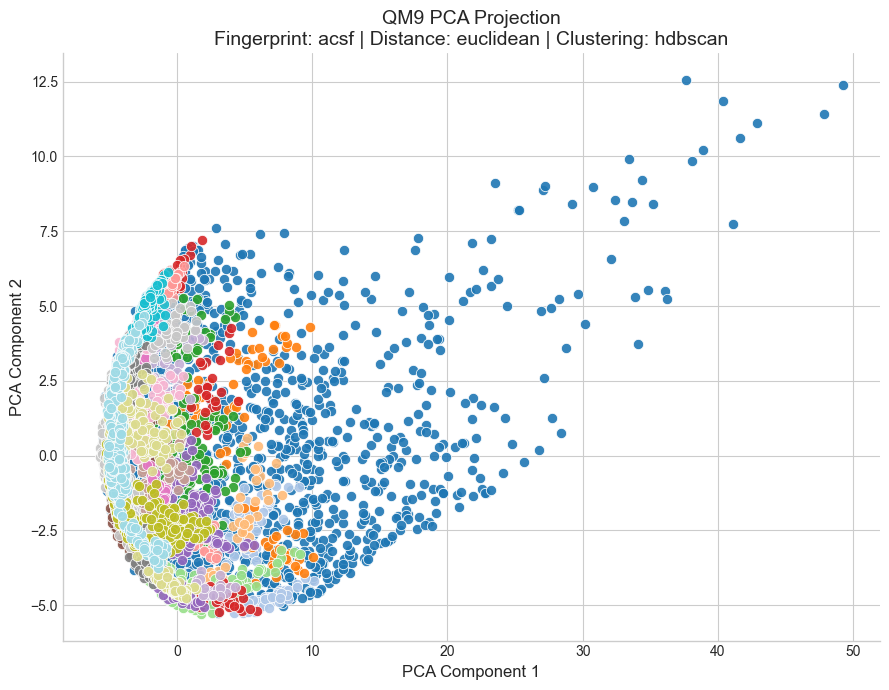

2026-05-07 08:33:08.025 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hdbscan_projection.png


{'coords': array([[ 2.04727382,  6.15755566],
        [ 0.78826238,  2.45460851],
        [ 2.92098853,  4.15312476],
        ...,
        [-2.79477572,  1.8261195 ],
        [-3.19933111, -0.19352697],
        [ 1.28699442,  5.14097104]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_hdbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'hdbscan'}

In [45]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [27]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (22, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,2838,0.774492,0.0,121.188161,-0.030655,41.392882,0.845609,12.854014,8.673362,1.381959,0.175476,0.008457,2.650106,17.44926,2.037105,2.391473,0.102836,0.253669,0.643494,0.984144,2.187456,6.032417,0.663143,1.400634,3.959479,6.447146,13.231149,1.259999,0.002114,0.328048,0.035236,0.188161,0.167724,0.002114,0.050388,0.133192,0.528541,0.000352,2.914733,73.456762,-6.581453,0.055004,6.636472,1208.217421,3.782142,-11170.804857,-11170.572099,-11170.546399,-11171.72141,31.261533,-72.908358,-73.33591,-73.750539,-67.90773,3.697281,1.371695,1.094567,0.009161,0.947851,0.047921,0.0,65.715292,17.0895,17.195208,13.231149,796,"""Acyclic""",17.195208,206,"""Acyclic""",17.195208,1,null,0.0
0,61,0.768963,0.0,128.688525,-0.672131,65.459016,0.733704,13.050607,8.983607,1.147541,0.131148,0.0,3.983607,17.934426,2.01423,2.57377,0.019672,0.278689,0.701639,1.967213,2.819672,6.311475,0.098361,1.393443,3.508197,6.442623,13.737705,1.254727,0.0,0.459016,0.098361,0.491803,0.557377,0.016393,0.04918,0.131148,0.47541,0.0,3.340613,71.25,-6.53729,-0.192666,6.344803,1195.046468,3.697853,-12351.549917,-12351.313316,-12351.287734,-12352.471968,31.763,-71.433676,-71.850416,-72.260365,-66.441623,2.943441,1.356376,1.002864,0.0,0.901639,0.0,0.0,83.606557,13.114754,3.278689,13.737705,45,"""O=C1CCCN1""",6.557377,20,"""C1CCCC1""",21.311475,1,null,0.0
1,104,0.917536,0.0,125.317308,-0.471154,45.605769,0.895799,12.797244,9.0,2.326923,0.057692,0.0,3.0,16.317308,2.147706,1.211538,0.040064,0.272436,0.6875,1.134615,2.519231,6.548077,0.240385,1.634615,4.125,5.653846,14.961538,1.284321,0.009615,0.403846,0.038462,0.115385,0.278846,0.0,0.086538,0.336538,0.557692,0.0,3.255618,70.38625,-6.609881,-0.529078,6.080698,1046.454373,3.390764,-11915.12361,-11914.915368,-11914.889705,-11916.00401,29.128961,-70.128171,-70.536592,-70.92209,-65.38154,2.957171,1.553079,1.209892,0.0,0.019231,0.0,0.0,93.269231,5.769231,0.961538,14.961538,94,"""C1C2NC3C1C23""",2.884615,63,"""CC1CCCC1""",5.769231,1,null,0.0
2,158,0.819095,0.0,122.835443,-0.170886,28.189873,0.868072,12.761923,8.955696,2.689873,0.088608,0.0,2.0,18.322785,2.152902,1.227848,0.055003,0.200874,0.744123,0.867089,1.449367,7.316456,0.379747,1.386076,5.189873,5.879747,15.018987,1.275253,0.006329,0.189873,0.018987,0.031646,0.094937,0.0,0.0,0.202532,0.310127,0.0,2.920799,76.611203,-6.423902,0.182833,6.606838,1083.291347,4.005615,-10889.703267,-10889.491971,-10889.466272,-10890.584207,30.096057,-77.062786,-77.540104,-77.973616,-71.791119,3.178727,1.498266,1.227228,0.0,0.949367,0.0,0.0,91.139241,8.860759,0.0,15.018987,125,"""c1cc[nH]c1""",3.797468,86,"""C1CCCC1""",7.594937,1,null,0.0
3,55,0.797291,0.0,124.581818,-0.618182,45.563636,0.722243,12.915792,8.981818,2.236364,0.272727,0.0,3.0,17.781818,2.121446,1.254545,0.003636,0.394545,0.601818,1.654545,2.072727,7.690909,0.018182,2.

# KMeans

In [28]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
X = np.array(df['acsf_embedding'].to_list())
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))


(array([0, 1, 2], dtype=int32), array([ 726, 2687, 1587]))


In [29]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-05-06 09:43:41.503 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-06 09:43:41.504 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-06 09:44:30.297 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-06 09:44:30.307 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-06 09:44:30.548 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-06 09:44:30.616 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [30]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,726,0.825458,0.0,121.104683,-0.402204,55.995868,0.622429,12.999138,8.706612,1.381543,0.451791,0.006887,3.527548,16.190083,2.038581,1.742424,0.082422,0.459216,0.458363,1.545455,2.615702,6.219008,0.451791,2.263085,2.464187,6.260331,13.179063,1.258625,0.001377,0.104683,0.090909,0.450413,0.297521,0.004132,0.015152,0.057851,…,3.363918,71.772534,-6.277078,-0.300255,5.976868,1106.71578,3.341083,-11315.394375,-11315.177154,-11315.151442,-11316.288859,29.363231,-67.63512,-68.02014,-68.396049,-63.03265,3.693963,1.496619,1.117986,0.035813,0.976584,0.157025,0.0,-0.563361,47.245179,43.663912,9.090909,13.179063,334,"""Acyclic""",9.090909,94,"""C1CCCC1""",26.997245,1,null,0.0
1,2687,0.684956,0.0,123.489766,0.248604,30.463342,0.90349,12.847765,8.773353,1.542985,0.023074,0.0,2.009304,20.212505,2.044932,2.967622,0.043328,0.109822,0.84685,0.895422,1.682173,6.922218,0.299963,0.713807,5.750279,6.524377,13.761816,1.256052,0.0,0.465947,0.002977,0.077782,0.120581,0.001489,0.025307,0.098623,…,2.432568,78.13502,-6.569887,0.850829,7.420726,1266.844817,4.663177,-10951.980268,-10951.733278,-10951.707584,-10952.90774,33.824194,-82.304908,-82.827564,-83.315143,-76.490369,3.249749,1.310657,1.076042,0.0,1.629326,0.0,0.0,6.208039,84.51805,2.307406,13.174544,13.761816,722,"""Acyclic""",13.174544,190,"""C1CC1""",13.844436,1,null,0.0
2,1587,0.85758,0.0,121.830498,-0.046629,35.426591,0.954437,12.731548,8.803403,2.10586,0.101449,0.011972,2.371141,16.63201,2.110146,1.42155,0.104168,0.232624,0.663208,0.722117,2.098299,6.081285,0.698173,1.436673,4.297417,6.068683,14.164461,1.27655,0.004411,0.3661,0.026465,0.064272,0.088847,0.0,0.079395,0.226213,…,2.736701,72.331934,-6.607766,-0.130654,6.477088,1093.457548,3.536585,-11327.659583,-11327.445133,-11327.419452,-11328.549463,29.675365,-71.613828,-72.031504,-72.427313,-66.789272,3.44605,1.504782,1.215524,0.0,0.233144,0.013863,0.0,2.200378,83.868935,10.018904,6.112161,14.164461,714,"""Acyclic""",6.112161,258,"""C1CCCC1""",8.065532,1,null,0.0
